**Image Processing  - Mobina Vafaei 25120465 - Best Model: SVM (Model 5)**

###**Load Data**

In [ ]:
# Extract the .rar file
!apt-get -y install unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from random import randint
from random import seed
from tqdm import tqdm

In [ ]:
# Image Processing & Feature Extraction
import cv2
from skimage.feature import hog

In [ ]:
# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score

In [ ]:
RANDOM_SEED = 100

In [ ]:
# extract .rar file
!unrar x "/content/train_images.rar"
!unrar x "/content/test_images.rar"

Streaming output truncated to the last 5000 lines.
Extracting  train_images/6406.jpg                                         60%  OK 
Extracting  train_images/6407.jpg                                         60%  OK 
Extracting  train_images/6408.jpg                                         60%  OK 
Extracting  train_images/6409.jpg                                         60%  OK 
Extracting  train_images/641.jpg                                          60%  OK 
Extracting  train_images/6410.jpg                                         60%  OK 
Extracting  train_images/6411.jpg                                         60%  OK 
Extracting  train_images/6412.jpg                                         60%  OK 
Extracting  train_images/6413.jpg                                         60%  OK 
Extracting  train_images/6414.jpg                                         60%  OK 
Extracting  train_images/6415

In [ ]:
# load training data
df_train = pd.read_csv(os.path.join("/content/train.csv"))

# summarise the details
print(f'Number of entries: {len(df_train)}')
df_train.head()

Number of entries: 10000


,id,label
0,1,cat
1,2,dog
2,3,cat
3,4,cat
4,5,cat


In [ ]:
# load testing data
df_test = pd.read_csv(os.path.join("/content/test.csv"))

# summarise the details
print(f'Number of entries: {len(df_test)}')
df_test.head()

Number of entries: 1000


,id
0,1
1,2
2,3
3,4
4,5


<Axes: xlabel='label', ylabel='count'>

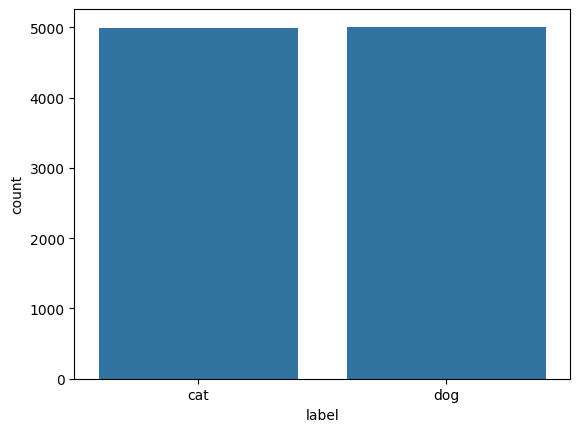

In [ ]:
# Summarise label details in training data
sns.countplot(x=df_train['label'])

In [ ]:
# method to load images in a folder
def load_images(ids, folder_path, dim=None):
  images = []
  for id in tqdm(ids):
    image_path = os.path.join(folder_path, f'{id}.jpg')
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


# checking for loaded correctly
    if img is None:
      print("Missing:", image_path)
      continue

# resize image if target dimension is provided
    if dim is not None:
      img = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
    images.append(img)
  return images

In [ ]:
base_dim = (200, 200)

# load train images
train_image_folder = os.path.join('/content/train_images')
train_images = load_images(df_train['id'], train_image_folder, base_dim)
print(f'Number of training images loaded: {len(train_images)}')

100%|██████████| 10000/10000 [00:10<00:00, 948.15it/s]

Number of training images loaded: 10000


In [ ]:
base_dim = (200, 200)

# load test images
test_image_folder = os.path.join("/content/test_images")
test_images = load_images(df_test['id'], test_image_folder, base_dim)
print(f'Number of testing images loaded: {len(test_images)}')

100%|██████████| 1000/1000 [00:00<00:00, 1002.22it/s]

Number of testing images loaded: 1000


###**Preprocessing and model generation**

In [ ]:
# calculate evaluation results
def evaluate(actuals, predictions, class_names):

  # calculate accuracy
  accuracy = metrics.accuracy_score(actuals, predictions)
  print(f'Accuracy: {accuracy}')

  # calculate F1-score
  f1 = metrics.f1_score(actuals, predictions, average='weighted')
  print(f'F1-score: {f1}')

  # plot confusion matrix
  confusion_matrix = metrics.confusion_matrix(actuals, predictions, labels=class_names)
  disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=class_names)
  disp.plot()
  plt.show()

##**Logistic Regression**

In [ ]:
# Logistic Regression
def get_LR_predictions(X_train, X_val, y_train, y_val):

  # build model
  clf = LogisticRegression(random_state=RANDOM_SEED, max_iter=5000)
  clf.fit(X_train, y_train)

  # Make predictions on test data
  y_pred = clf.predict(X_val)

  # evalution
  evaluate(y_val, y_pred, clf.classes_)
  return clf

###**Model 1**


*   Preprocessing - gray scaling
*   Features - image vector


*   Model - Logistic Regression





In [ ]:
def get_features_m1(images):

  features_list = []
  for img in images:
    # image preprocessing - gray scaling
    img_grayscaled = img

    # image vectorisation
    features = img_grayscaled.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m1(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.513
F1-score: 0.5122331138609946


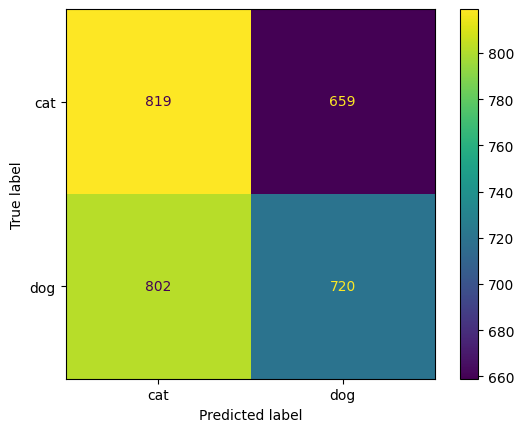

In [ ]:
# train model 1
m1 = get_LR_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m1(test_images)
print(features_test.shape)

# get model predictions
predictions = m1.predict(features_test)
print(predictions)

(1000, 40000)
['cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog'
 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat'
 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat'
 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat'
 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog'
 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat'
 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat'
 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog'
 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 

###**Model 2**


*   Preprocessing - gray scaling, smoothing
*   Features - image vector



*   Model - Logistic Regression



Image Id: 2386
Image Id: 7528
Image Id: 7453
Image Id: 2863
Image Id: 6439


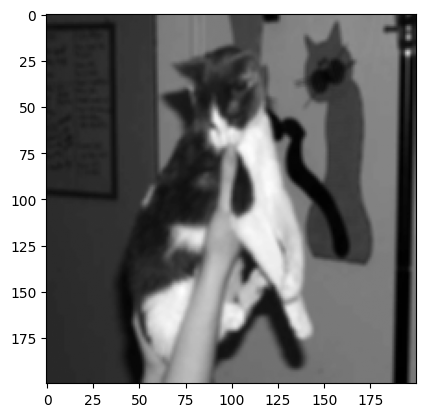

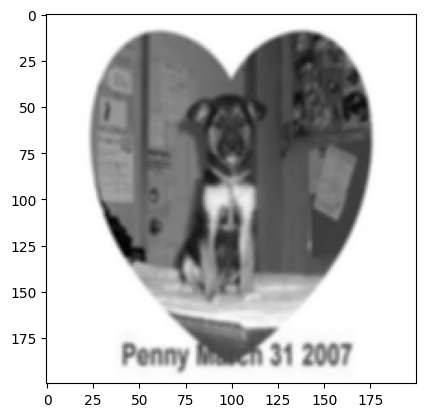

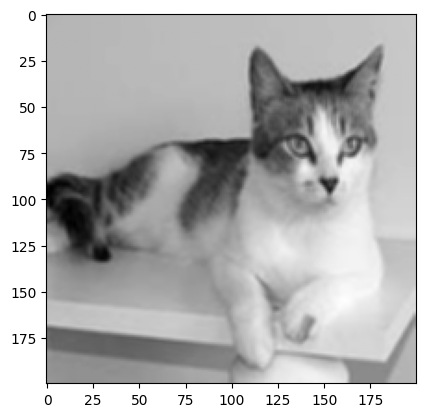

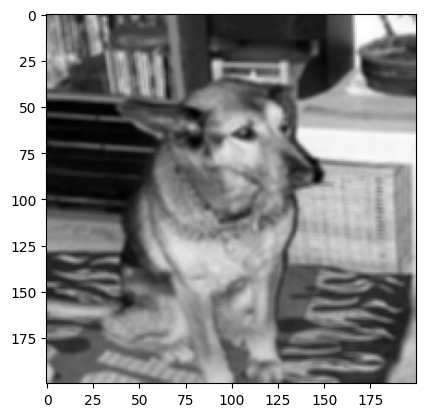

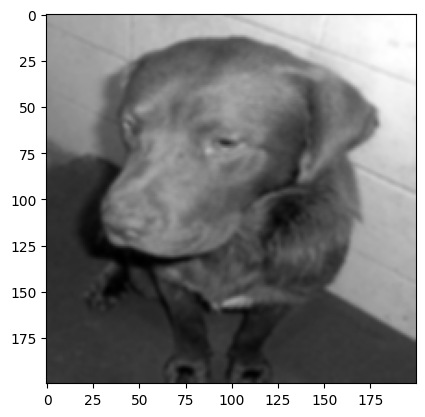

In [ ]:
seed(RANDOM_SEED)
sample_images = []

for i in range(5):
  value = randint(0, len(train_images)-1)
  print(f'Image Id: {value}')
  sample_images.append(train_images[value])

# apply preprocessing
for img in sample_images:
  img_grayscaled = img
  img_blurred = cv2.GaussianBlur(img_grayscaled,(3,3), 2)

  plt.imshow(img_blurred, cmap='gray')
  plt.show()

In [ ]:
# Model 2
def get_features_m2(images):

  features_list = []
  for img in images:
    # image preprocessing - gray scaling + smoothing
    img_grayscaled = img
    img_blurred = cv2.GaussianBlur(img_grayscaled, (3,3), 2)

    # image vectorisation
    features = img_blurred.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m2(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.5076666666666667
F1-score: 0.5071347419175157


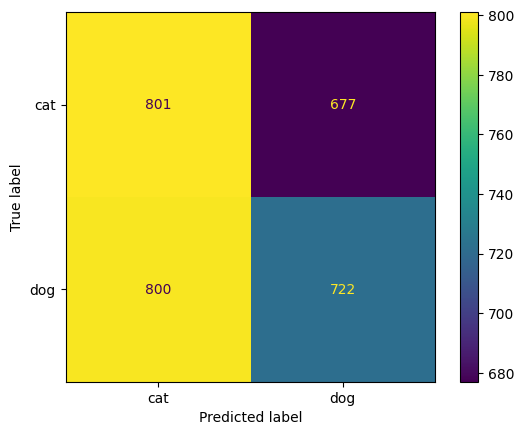

In [ ]:
# train model 2
m2 = get_LR_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m2(test_images)
print(features_test.shape)

# get model predictions
predictions = m2.predict(features_test)
print(predictions)

(1000, 40000)
['cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog'
 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog'
 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat'
 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat'
 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog'
 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog'
 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog'
 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat'
 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog'
 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat'
 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog'
 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 

###**Model 3**


*   Preprocessing - gray scaling
*   Features - edge map to vector (Canny edge detection )



*   Model - Logistic Regression



In [ ]:
# method to get image features
def get_features_m3(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    edges_canny = cv2.Canny(img_grayscaled, 100, 200)
    features = edges_canny.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m3(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.557
F1-score: 0.556789282672201


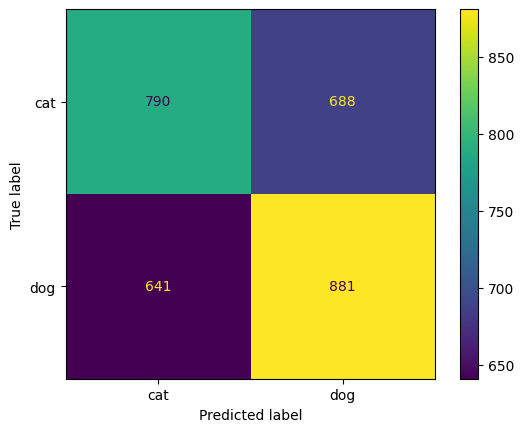

In [ ]:
# train model 3
m3 = get_LR_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m3(test_images)
print(features_test.shape)

# get model predictions
predictions = m3.predict(features_test)
print(predictions)

(1000, 40000)
['dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat'
 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog'
 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat'
 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'cat'
 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat'
 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat'
 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog'
 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 

###**Model 4**


*   Preprocessing - gray scaling
*   Features - HOG feature



*   Model - Logistic Regression



In [ ]:
# Model 4
def get_features_m4(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    # Resize image if necessary
    img_resized = cv2.resize(img_grayscaled, (64, 128))

    features, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=True)

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m4(train_images)
print(features_train.shape)

(10000, 3780)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.69
F1-score: 0.6900132268782967


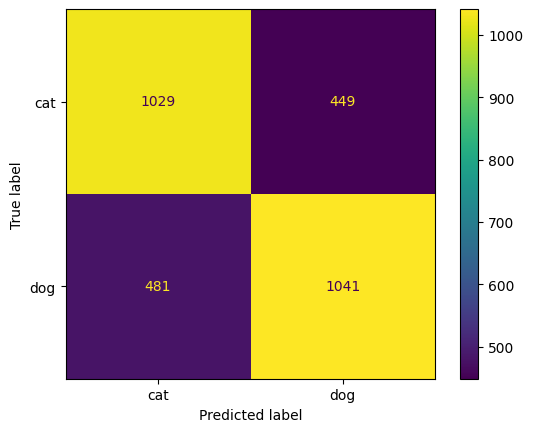

In [ ]:
# train model
m4 = get_LR_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m4(test_images)
print(features_test.shape)

# get model predictions
predictions = m4.predict(features_test)
print(predictions)

(1000, 3780)
['dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog'
 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat'
 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog'
 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat'
 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat'
 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'cat'
 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat'
 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog'
 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat'
 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog'
 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' '

##**K-Nearest Neighbors**

In [ ]:
# K-Nearest Neighbors
def get_KNN_predictions(X_train, X_val, y_train, y_val):

  # build model
  clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
  clf.fit(X_train, y_train)

  # Make predictions on test data
  y_pred = clf.predict(X_val)

  # evalution
  evaluate(y_val, y_pred, clf.classes_)
  return clf

###**Model 1**


*   Preprocessing - gray scaling
*   Features - image vector



*   Model - K-Nearest Neighbors



In [ ]:
def get_features_KNN_m1(images):

  features_list = []
  for img in images:
    # image preprocessing - gray scaling
    img_grayscaled = img

    # image vectorisation
    features = img_grayscaled.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_KNN_m1(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.5483333333333333
F1-score: 0.5438326468698157


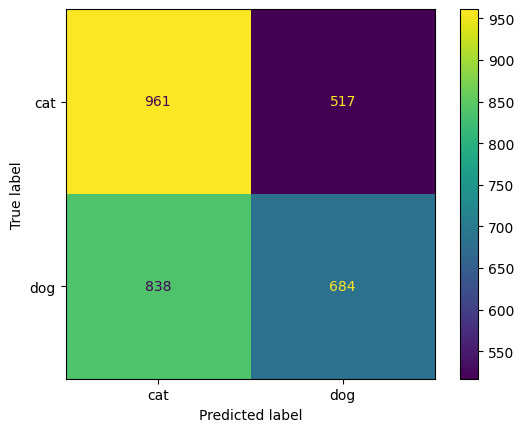

In [ ]:
# train model 1
m1_KNN = get_KNN_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_KNN_m1(test_images)
print(features_test.shape)

# get model predictions
predictions = m1_KNN.predict(features_test)
print(predictions)

(1000, 40000)
['dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat'
 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog'
 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog'
 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog'
 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog'
 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat'
 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat'
 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat'
 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 

###**Model 2**


*   Preprocessing - gray scaling, smoothing
*   Features - image vector



*   Model - K-Nearest Neighbors



Image Id: 2386
Image Id: 7528
Image Id: 7453
Image Id: 2863
Image Id: 6439


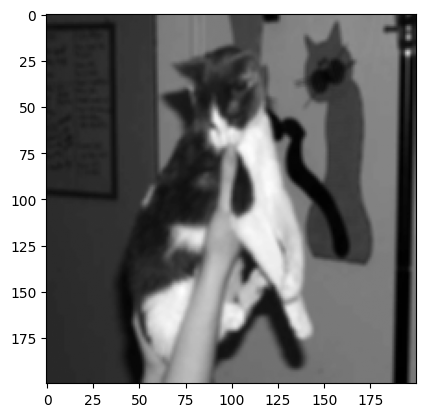

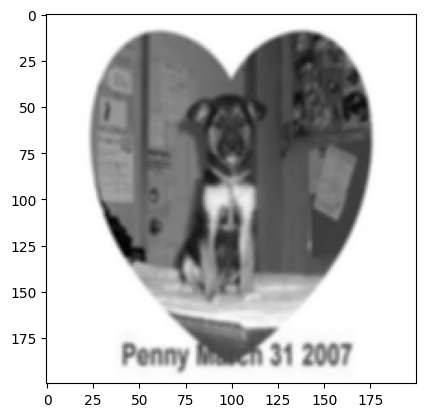

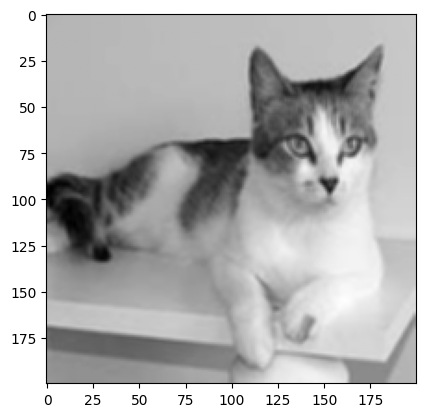

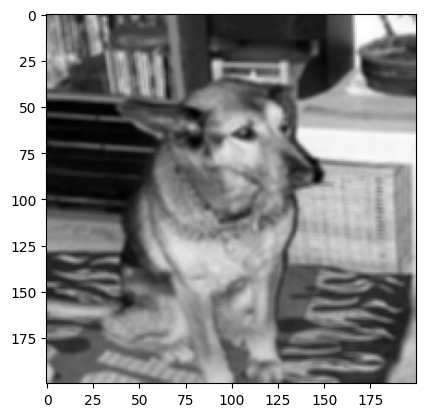

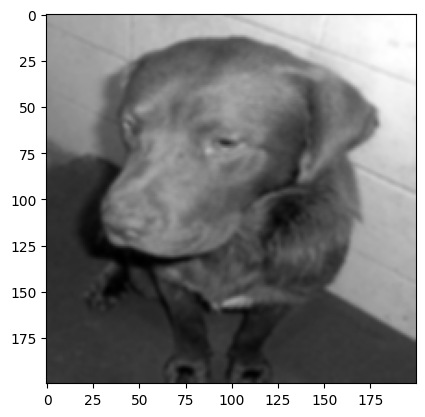

In [ ]:
seed(RANDOM_SEED)
sample_images = []

for i in range(5):
  value = randint(0, len(train_images)-1)
  print(f'Image Id: {value}')
  sample_images.append(train_images[value])

# apply preprocessing
for img in sample_images:
  img_grayscaled = img
  img_blurred = cv2.GaussianBlur(img_grayscaled,(3,3), 2)

  plt.imshow(img_blurred, cmap='gray')
  plt.show()

In [ ]:
# Model 2
def get_features_m2_KNN(images):

  features_list = []
  for img in images:
    # image preprocessing - gray scaling + smoothing
    img_grayscaled = img
    img_blurred = cv2.GaussianBlur(img_grayscaled, (3,3), 2)

    # image vectorisation
    features = img_blurred.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train_KNN = get_features_m2_KNN(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train_KNN, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.5566666666666666
F1-score: 0.5557781258359293


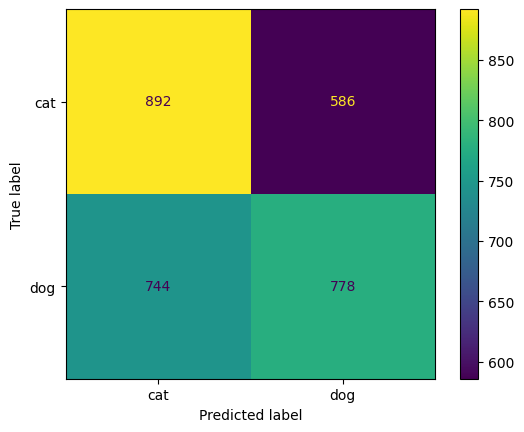

In [ ]:
# train model 2
m2_KNN = get_KNN_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test_KNN = get_features_m2_KNN(test_images)
print(features_test_KNN.shape)

# get model predictions
predictions = m2_KNN.predict(features_test_KNN)
print(predictions)

(1000, 40000)
['dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat'
 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog'
 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog'
 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog'
 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat'
 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat'
 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 

###**Model 3**


*   Preprocessing - gray scaling
*   Features - edge map to vector (Canny edge detection )



*   Model - K-Nearest Neighbors


In [ ]:
# method to get image features
def get_features_m3_KNN(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    edges_canny = cv2.Canny(img_grayscaled, 100, 200)
    features = edges_canny.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m3_KNN(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.49633333333333335
F1-score: 0.3678681615871927


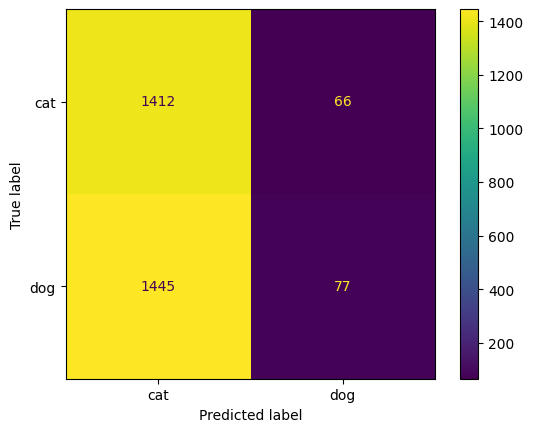

In [ ]:
# train model 3
m3_KNN = get_KNN_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m3_KNN(test_images)
print(features_test.shape)

# get model predictions
predictions = m3_KNN.predict(features_test)
print(predictions)

(1000, 40000)
['cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 

###**Model 4**


*   Preprocessing - gray scaling
*   Features - HOG feature



*   Model - K-Nearest Neighbors



In [ ]:
# Model 4
def get_features_m4_KNN(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    # Resize image if necessary
    img_resized = cv2.resize(img_grayscaled, (64, 128))

    features, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=True)

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m4_KNN(train_images)
print(features_train.shape)

(10000, 3780)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.585
F1-score: 0.5216499239796031


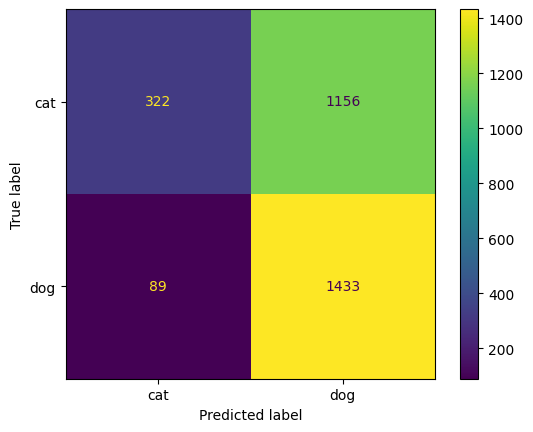

In [ ]:
# train model
m4_KNN = get_KNN_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m4_KNN(test_images)
print(features_test.shape)

# get model predictions
predictions = m4_KNN.predict(features_test)
print(predictions)

(1000, 3780)
['dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog'
 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog'
 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog'
 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog'
 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' '